In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_10540/2790968301.py:20: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\Delta\Delta G$ (kcal/mol) - Modelo Humano', fontsize=16)
/tmp/ipykernel_10540/2790968301.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='Result', y='ddG_Humano_AF', order=orden_clinico, palette='coolwarm', showfliers=False)


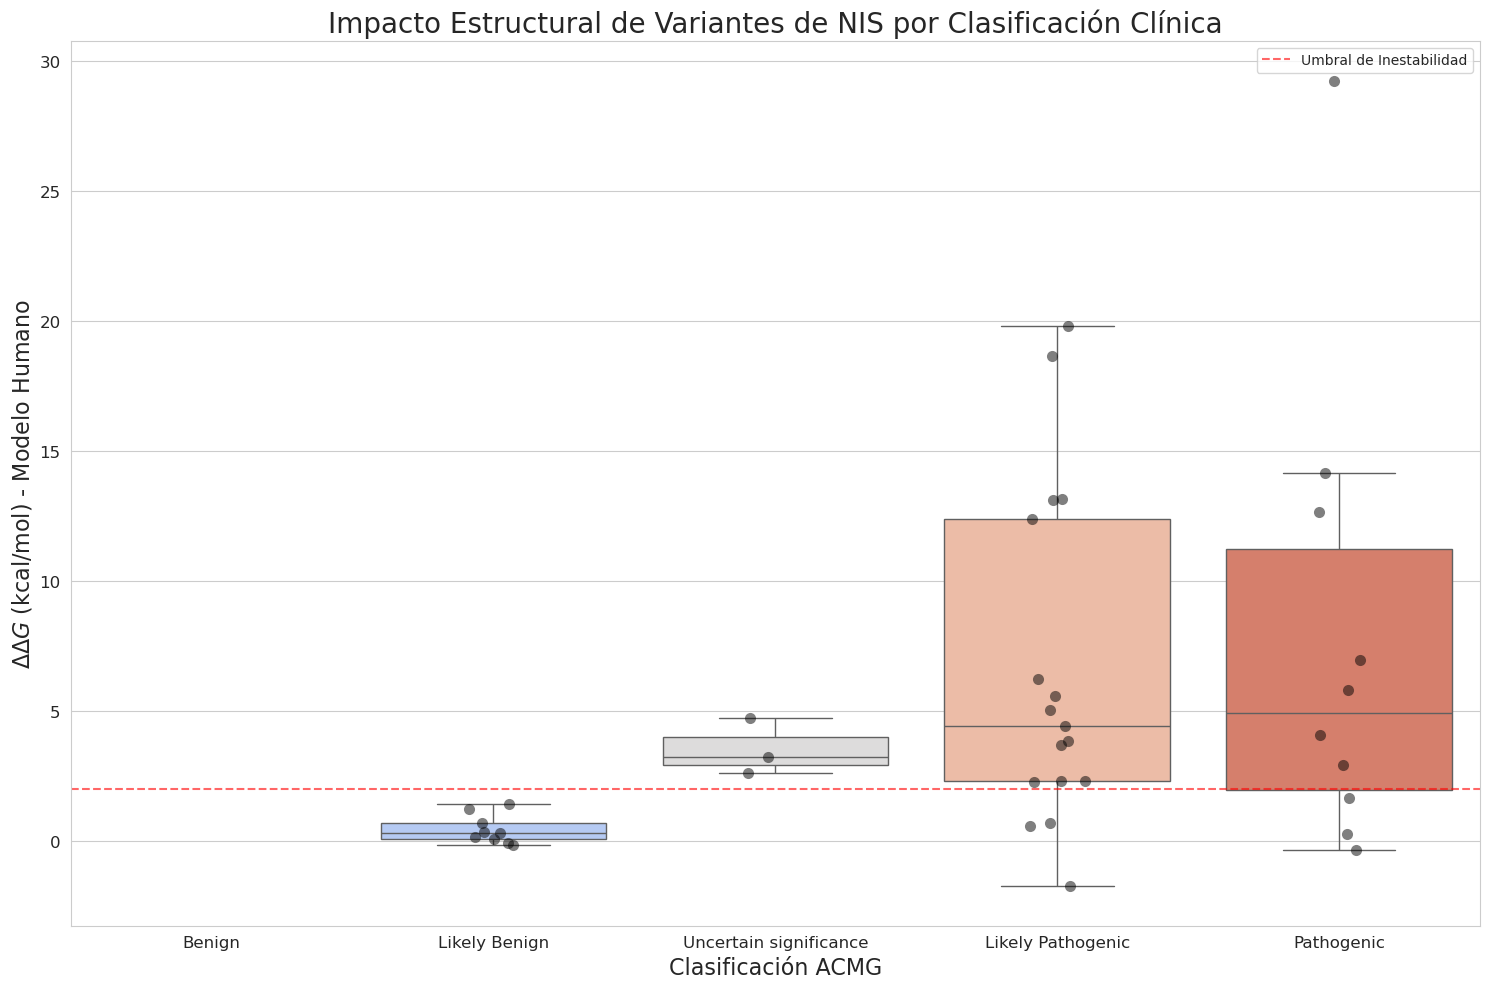

In [ ]:
# Cargamos el reporte
df = pd.read_csv('~/Downloads/REPORTE_FINAL_PULIDO.csv')

# PASO CLAVE: Convertimos los guiones de vuelta a NaN para que Python pueda graficar
cols_ddg = ['ddG_7UUY', 'ddG_7UUZ', 'ddG_7UV0', 'ddG_Humano_AF']
for col in cols_ddg:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Orden lógico clínico para el eje X
orden_clinico = ['Benign', 'Likely Benign', 'Uncertain significance', 'Likely Pathogenic', 'Pathogenic']

plt.figure(figsize=(15, 15)) # El tamaño que pediste
sns.set_style("whitegrid")

# Graficamos
ax = sns.boxplot(data=df, x='Result', y='ddG_Humano_AF', order=orden_clinico, palette='coolwarm', showfliers=False)
sns.stripplot(data=df, x='Result', y='ddG_Humano_AF', order=orden_clinico, color='black', alpha=0.5, size=8)

plt.title('Impacto Estructural de Variantes de NIS por Clasificación Clínica', fontsize=20)
plt.ylabel('$\Delta\Delta G$ (kcal/mol) - Modelo Humano', fontsize=16)
plt.xlabel('Clasificación ACMG', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Agregamos una línea roja en el umbral de 2 kcal/mol (punto de corte típico)
plt.axhline(y=2, color='red', linestyle='--', alpha=0.6, label='Umbral de Inestabilidad')
plt.legend()

plt.tight_layout()
plt.savefig('Boxplot_NIS_Final.png', dpi=300)
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_10540/3057260885.py:7: SyntaxWarning: invalid escape sequence '\D'
  sns.heatmap(df_heat, cmap='YlOrRd', annot=True, fmt=".2f", cbar_kws={'label': '$\Delta\Delta G$ (kcal/mol)'})


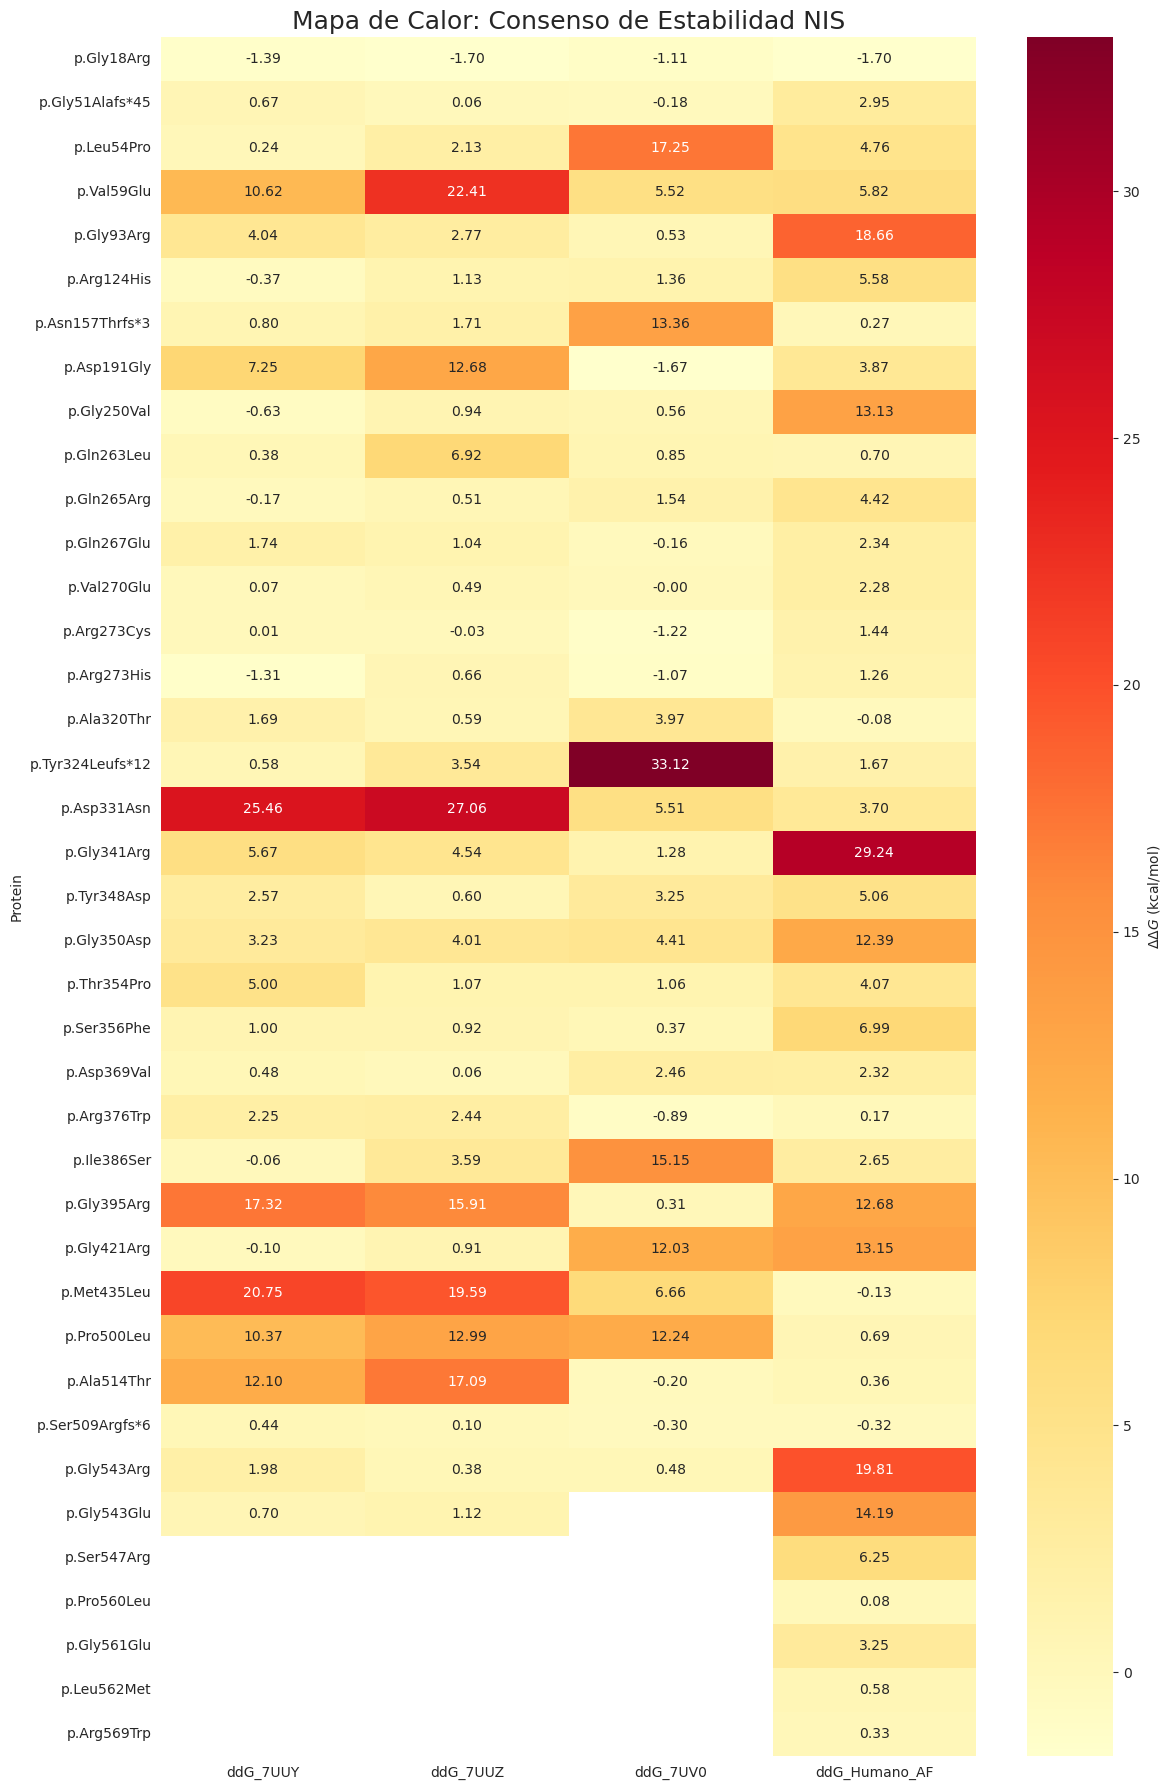

In [12]:
# Filtramos solo las missense que tienen al menos un dato de FoldX
df_heat = df.dropna(subset=cols_ddg, how='all')
df_heat = df_heat.set_index('Protein')[cols_ddg]

plt.figure(figsize=(12, 18))
# Usamos annot=True para que ponga los numeritos adentro
sns.heatmap(df_heat, cmap='YlOrRd', annot=True, fmt=".2f", cbar_kws={'label': '$\Delta\Delta G$ (kcal/mol)'})

plt.title('Mapa de Calor: Consenso de Estabilidad NIS', fontsize=18)
plt.tight_layout()
plt.savefig('Heatmap_NIS_Consenso.png', dpi=300)
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_10540/851639512.py:7: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('$\Delta\Delta G$ Humano (AlphaFold)', fontsize=14)
/tmp/ipykernel_10540/851639512.py:8: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\Delta\Delta G$ Rata (7UUY)', fontsize=14)


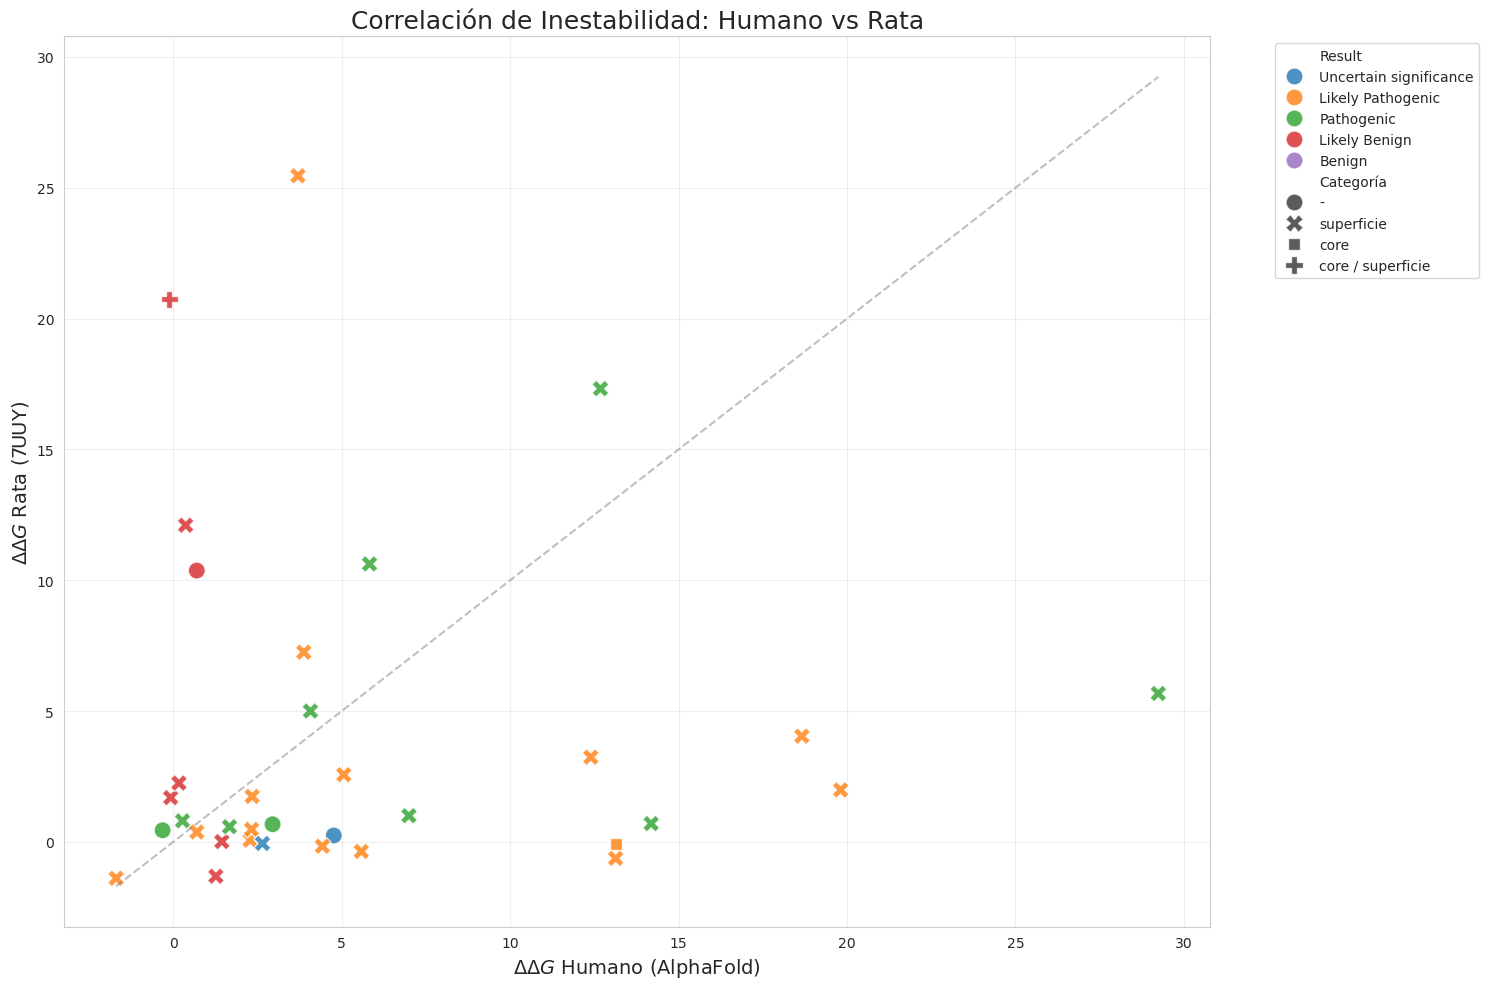

In [13]:
plt.figure(figsize=(15, 10))

# Graficamos todas
sns.scatterplot(data=df, x='ddG_Humano_AF', y='ddG_7UUY', hue='Result', style='Categoría', s=150, alpha=0.8)

plt.title('Correlación de Inestabilidad: Humano vs Rata', fontsize=18)
plt.xlabel('$\Delta\Delta G$ Humano (AlphaFold)', fontsize=14)
plt.ylabel('$\Delta\Delta G$ Rata (7UUY)', fontsize=14)

# Dibujamos una línea diagonal de 45 grados (si caen ahí, hay consenso total)
plt.plot([df['ddG_Humano_AF'].min(), df['ddG_Humano_AF'].max()], 
         [df['ddG_Humano_AF'].min(), df['ddG_Humano_AF'].max()], 
         color='grey', linestyle='--', alpha=0.5)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Scatter_Correlacion_NIS.png', dpi=300)
plt.show()